# Duffing data collection

We collect nominal and excursion data for KIND training. To this end, we create a Duffing environment that is then run under a baseline LQR policy.

In [1]:
# --! include root folder into PYTHONPATH

import os
import sys

curr_dir = os.getcwd()
root_dir = os.path.abspath(os.path.join(curr_dir, '..', '..'))
sys.path.append(root_dir)

data_dir = '../../data/duffing'

# --! import Python libraries

import torch
import numpy as np
import matplotlib.pyplot as plt

import kind
import example_duffing
import util_data
import reinforcement_learning as rl

## Create a Duffing oscillator

The oscillator is represented by an environment. This environment is parametrized by Duffing parameters, such as $\alpha$, $\beta$, etc. We intentionally introduce a modeling mismatch in the design of a linear quadratic regulator (LQR) to prevent the LQR from stabilizing the Duffing too aggressively. This way, the LQR lets the Duffing transition between its two potential wells.

In [2]:
# --! define Duffing parameters --!

# --! define parameters of a nominal Duffing which is supposed to be stabilized by an LQR
duffing_alpha_nom = -1.0
duffing_delta_nom = 0.5

# --! define parameters of an anomalous Duffing which exhibits excursions from one well to the other
duffing_alpha = -110.0
duffing_beta = 140.0
duffing_gamma = 70.0
duffing_delta = duffing_delta_nom

In [3]:
# --! make a base policy --!

state_ndim = 2
action_ndim = 1

state_cost = 1.0 * np.eye(state_ndim)
action_cost = 10.0 * np.eye(action_ndim)

# --! we aim to capture the Duffing in well (1,0)
setpoint = [1.0, 0.0]
dt = 1e-2

base_policy, _ = example_duffing.make_base_policy(
    duffing_alpha_nom, duffing_delta_nom,
    q=state_cost, r=action_cost,
    dt=dt,
    setpoint=setpoint)


We define a very basic reward function, which penalizes state deviation and effort applied. Mathematically the reward is
$$\mathcal{R}(x,u) = - (x-x^\star)^\top Q \, (x-x^\star) - u^\top R \,u,$$
where $x^\star$ is a setpoint.

In [4]:
# --! define a Duffing reward function --!

reward_fn = example_duffing.reward(state_cost, action_cost, setpoint)

We wrap created Duffing environment with an adapter to allow working with a numpy-based Duffing model in a torch environment.

In [5]:
# --! make a Duffing oscillator --!

env = example_duffing.environment(
    reward_fn,
    alpha=duffing_alpha, beta=duffing_beta, gamma=duffing_gamma, delta=duffing_delta,
    dt_control=dt)

env = example_duffing.environment_adapter(env)

## Collect a Duffing replay trajectory

In [6]:
# --! number of observation samples here is a lookback window size that will later be used for KIND model
obs_nsample = 64

# --! define some number of samples to skip in order to bypass the initial transient
skip_nsample = 10 * obs_nsample

residual_policy = None # there is no residula policy in the beginning
env_ic = torch.zeros(1,1,2) # zero initial condition

replay = env.replay(env_ic, rl.policies(base_policy, residual_policy), obs_nsample, skip_nsample)

## Process replay results

Here the processing of the Duffing replay means extracting nominal and excursion data snippets that will then be used for KIND training. Due to purely periodic nature of the current Duffing implementation, e.g. no phase noise, the extraction is performed manually. Of course, other automated methods are possible. When performing the extraction, we pay attention to a boundary between the lookback and forecast windows. This is the boundary at which KIND will start its predictions. The lookback window will only help KIND as history information. Consequently, when choosing the start of nominal or excursion data we need to look at the boundary, not at the start of a lookback window. The same with the end of data: we look at the boundary, not the end of a forecast window.

nominal region sample number: 253
excursion region sample number: 460
fore samples number: 32
back samples number: 64
window samples number: 96
replay shape for KIND training: torch.Size([1, 619, 3])
replay shape for paper: torch.Size([1, 669, 3])



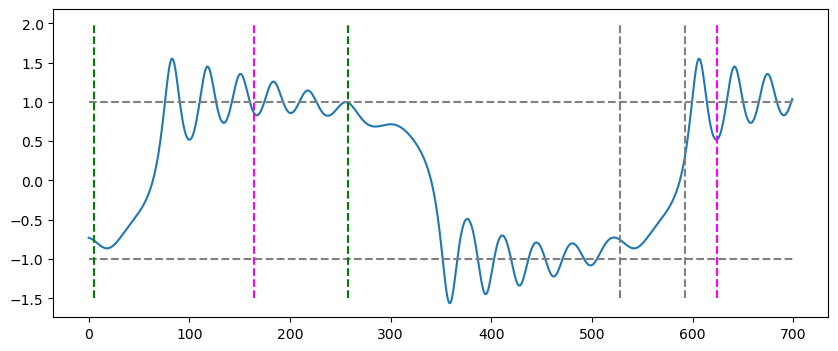

In [7]:
# --! plot results --!

back, _, _, _ = map(torch.cat, zip(*replay.buffer))
state = back[:, [-1]]

traj_start = 700

start_nom = 5
end_nom = 258
size_nom = end_nom - start_nom
print(f'nominal region sample number: {size_nom}')

s_nom = torch.transpose(state, 0, 1)
s_nom = s_nom[[0], -traj_start+start_nom:-traj_start+end_nom, :]

start_exc = 164
end_exc = 624
size_exc = end_exc - start_exc
print(f'excursion region sample number: {size_exc}')

s_exc = torch.transpose(state, 0, 1)
s_exc = s_exc[[0], -traj_start+start_exc:-traj_start+end_exc, :]

window_fore = 32
window_back = 2 * window_fore
print(f'fore samples number: {window_fore}')
print(f'back samples number: {window_back}')
window_nsample = window_back + window_fore
print(f'window samples number: {window_nsample}')

window_start = end_exc - window_nsample
window_mid = window_start + window_back
window_end = window_start + window_nsample

s_all = torch.transpose(state, 0, 1)
s_all = s_all[[0], -traj_start+start_nom:-traj_start+end_exc, :]
print(f'replay shape for KIND training: {s_all.shape}')

s_paper = torch.transpose(state, 0, 1)
s_paper = s_paper[[0], -traj_start+start_nom:-traj_start+end_exc+50, :]
print(f'replay shape for paper: {s_paper.shape}')
print('')

with torch.no_grad():
    plt.figure(figsize=(10,4))

    plt.plot(state[-traj_start:, 0, 0])
    plt.plot([window_start,window_start],[-1.5,2], linestyle='dashed', color='gray')
    plt.plot([window_end,window_end],[-1.5,2], linestyle='dashed', color='gray')
    plt.plot([window_mid,window_mid],[-1.5,2], linestyle='dashed', color='gray')
    plt.plot([0, traj_start],[1,1], linestyle='dashed', color='gray')
    plt.plot([0, traj_start],[-1,-1], linestyle='dashed', color='gray')
    plt.plot([start_nom,start_nom],[-1.5,2], linestyle='dashed', color='green')
    plt.plot([end_nom,end_nom],[-1.5,2], linestyle='dashed', color='green')
    plt.plot([start_exc,start_exc],[-1.5,2], linestyle='dashed', color='magenta')
    plt.plot([end_exc,end_exc],[-1.5,2], linestyle='dashed', color='magenta')

    plt.show()


## Save data

Note that we do not make strict separation between training and evaluation data here. Our main intent in this example is to show how switching between models occurs based on uncertainty signals $\zeta^{\text{nom}}$ and $\zeta^{\text{exc}}$, not test the ability of KIND instantiation to generalize. To assess KIND from a machine learning perspective (with proper data splits, performance under various seeds, etc.), consider our MuJoCo example.

In [8]:
# --! save results --!

datasaved = True

if datasaved:

    s_ext1_nom = s_nom.clone()
    s_ext2_nom = s_nom.clone()
    s_ext3_nom = s_nom.clone()
    s_ext4_nom = s_nom.clone()
    s_ext_nom = torch.cat([s_nom, s_ext1_nom, s_ext2_nom, s_ext3_nom, s_ext4_nom], dim=0)
    print(f'nominal data saved with shape {s_ext_nom.shape}')
    print(f'excursion data saved with shape {s_exc.shape}')

    print(f'baseline data saved with shape {s_all.shape}')
    print(f'paper data saved with shape {s_paper.shape}')

    util_data.write_datafile(f'{data_dir}/nom', s_nom.numpy())
    util_data.write_datafile(f'{data_dir}/exc', s_exc.numpy())
    util_data.write_datafile(f'{data_dir}/baseline', s_all.numpy())
    util_data.write_datafile(f'{data_dir}/paper', s_paper.numpy())

nominal data saved with shape torch.Size([5, 253, 3])
excursion data saved with shape torch.Size([1, 460, 3])
baseline data saved with shape torch.Size([1, 619, 3])
paper data saved with shape torch.Size([1, 669, 3])
